1) try a rectangular kernel size for this dataset
2) try leakyRelu and Gelu and maybe relu6
3) try reducing out channels and increasing out channels
4) removing and changing relu positions
5) adding conv layers
6) try adamw instead of adam
7) try tweaking lr

In [1]:
import os
import shutil
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
from tqdm.auto import tqdm

In [8]:

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.Compose([
transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48,48)),
    transforms.ToTensor()  
    
])
transforms.RandomRotation(5)

RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)

In [12]:
from pathlib import Path
import random
from torch.utils.data import DataLoader, random_split, Subset

DATA_ROOT = Path('frames/dataset')
print(f'Using local dataset root: {DATA_ROOT.resolve()}')

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Dataset folder not found: {DATA_ROOT}')

base_dataset = ImageFolder(
    root=str(DATA_ROOT),
    transform=transform,
)

# Use a smaller, class-balanced subset so the local smoke-test training run completes quickly.
MAX_SAMPLES_PER_CLASS = 5000
class_to_indices = {}
for idx, (_, target) in enumerate(base_dataset.samples):
    class_to_indices.setdefault(target, []).append(idx)

selected_indices = []
for target in sorted(class_to_indices):
    selected_indices.extend(
        random.sample(
            class_to_indices[target],
            k=min(MAX_SAMPLES_PER_CLASS, len(class_to_indices[target])),
        )
    )
random.shuffle(selected_indices)

dataset = Subset(base_dataset, selected_indices)
dataset.classes = base_dataset.classes

print(f'Classes: {dataset.classes}')
print(f'Total samples: {len(dataset)}')

# Split into train/val/test with the same proportions as the original notebook.
total_size = len(dataset)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print('done')

Using local dataset root: C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\dataset
Classes: ['mouth_closed', 'talking', 'yawning']
Total samples: 15000
done


In [13]:
print(len(test_dataset))
print(len(train_dataset))
print(len(val_dataset))

3000
9000
3000


In [6]:
class CustomCNN(nn.Module):
    def __init__(self):
#Constructor
        super().__init__()
#Building first convolutional layer
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
        )
            
#First Rectified Linear Unit (ReLU)
        self.relu1 = nn.ReLU()

#First BatchNorm
        self.bn1 = nn.BatchNorm2d(32)
#First MaxPool layer
        self.pool1=nn.MaxPool2d(
            kernel_size=2,
            stride =2
        )
#First DropOut Layer
        self.dropout1 = nn.Dropout(0.25)
#2nd Conv Layer
        self.conv2 = nn.Conv2d(
            in_channels =32,
            out_channels=64,
            kernel_size=3
        )

#2nd ReLU Layer
        self.relu2=nn.ReLU()

#2nd BatchNorm
        self.bn2 = nn.BatchNorm2d(64)

#2nd MaxPool Layer
        self.pool2 = nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
#SECOND DropOut Layer
        self.dropout2 = nn.Dropout(0.25)


#3RDd Conv Layer
        self.conv3 = nn.Conv2d(
            in_channels =64,
            out_channels=64,
            kernel_size=3
        )

#3Rd ReLU Layer
        self.relu3=nn.ReLU()

#3Rd BatchNorm
        self.bn3 = nn.BatchNorm2d(64)

#3Rd MaxPool Layer
        self.pool3 = nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
#3RD DropOut Layer
        self.dropout3 = nn.Dropout(0.25)

        
# ----------------------- fully connected/dense layer part of CNN --------------------------------------------

        self.flatten=nn.Flatten()
        self.fc1= nn.Linear(
                in_features = 1024,
                out_features=128
            )
        self.relu_fc = nn.Linear(
                in_features =128,
                out_features=4
            )
        self.dropout_fc=nn.Dropout(0.5)

        self.fc2=nn.Linear(
                in_features=128,
                out_features=4
            )
    def forward(self,x):
        x=self.conv1(x)
        x=self.relu1(x)
        x=self.bn1(x)
        x=self.pool1(x)
        x=self.dropout1(x)

        x=self.conv2(x)
        x=self.relu2(x)
        x=self.bn2(x)
        x=self.pool2(x)
        x=self.dropout2(x)

        x=self.conv3(x)
        x=self.relu3(x)
        x=self.bn3(x)
        x=self.pool3(x)
        x=self.dropout3(x)

        x=self.flatten(x)
        x=self.fc1(x)
        x=self.dropout_fc(x)
        x=self.fc2(x)

        return x
            

In [9]:
model=CustomCNN()
model=model.to(device)

In [10]:
criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [14]:
from tqdm.auto import tqdm

best_acc = 0
best_epoch = 0
epochs = 50

for epoch in range(epochs):

    ##############################
    # TRAINING
    ##############################

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            train_acc=f"{train_acc:.2f}%"
        )

    ##############################
    # VALIDATION
    ##############################

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Validation Accuracy: {val_acc:.2f}%")

    ##############################
    # SAVE BEST MODEL
    ##############################

    if val_acc > best_acc:

        best_acc = val_acc
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            "best_eye_cnn.pth"
        )

        print("Best model saved.")

    ##############################
    # EARLY STOPPING
    ##############################

    if epoch - best_epoch >= 15:

        print(f"Early stopping at epoch {epoch+1}")

        break

Epoch 1/50:   0%|          | 0/282 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [10]:
import matplotlib.pyplot as plt
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [11]:
model.load_state_dict(torch.load("best_eye_cnn.pth"))

model.eval()

correct = 0
total = 0

wrong_images = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for i in range(images.size(0)):

            if predicted[i] != labels[i]:

                wrong_images.append((
                    images[i].cpu(),
                    labels[i].cpu(),
                    predicted[i].cpu()
                ))

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Wrong Predictions: {len(wrong_images)}")

Test Accuracy: 98.57%
Wrong Predictions: 251


In [12]:
print(f"Correct: {correct}")
print(f"Wrong: {len(wrong_images)}")
print(f"Total: {total}")
print(f"Correct + Wrong: {correct + len(wrong_images)}")
print(f"Dataset size: {len(test_dataset)}")

Correct: 17310
Wrong: 251
Total: 17561
Correct + Wrong: 17561
Dataset size: 17561


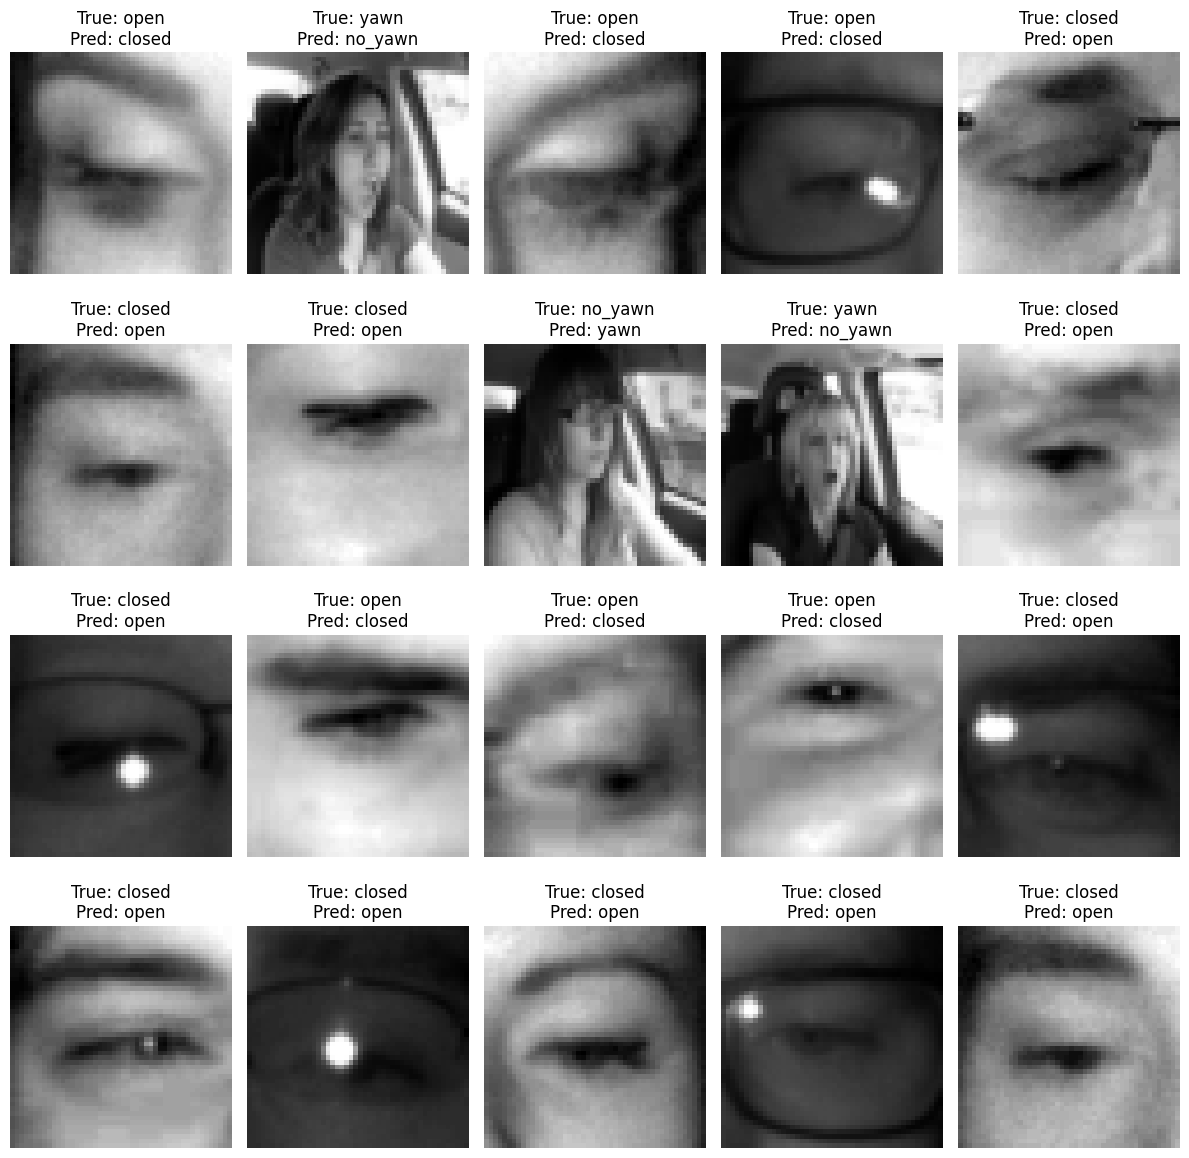

In [13]:
import matplotlib.pyplot as plt

classes = dataset.classes

plt.figure(figsize=(12, 12))

for i in range(min(20, len(wrong_images))):

    image, true_label, pred_label = wrong_images[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(
        f"True: {classes[true_label]}\nPred: {classes[pred_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()